In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load the dataset

In [11]:
df = pd.read_csv("../Dataset/S2_chest_data.csv")

### Filter the data

In [12]:
accept_label = [1, 2, 3, 4]
df = df[df["Label"].isin(accept_label)]

### Categorize the data

In [13]:
nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return 1
    elif label in nStr:
        return 0
    else:
        return "unknown"

df["Label"] = df["Label"].apply(apply_target)

df.head(2)

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp,Label
214583,0.8914,-0.1102,-0.2576,0.030945,-0.003708,5.710983,29.083618,1.191711,0
214584,0.8926,-0.1086,-0.2544,0.033646,-0.014145,5.719376,29.122437,1.139832,0


### Transform the EMG feature

In [17]:
df["EMG"] = df["EMG"].abs()

### Balancing the dataset

In [14]:
df['Label'].value_counts()

Label
0    1591799
1     430500
Name: count, dtype: int64

In [15]:
from sklearn.utils import resample

# majority class
low_stress = df[df["Label"] == 0]

# minority class
high_stress = df[df["Label"] == 1]

low_downsampled = resample(
    low_stress,
    replace=False,
    n_samples=len(high_stress),
    random_state=42
)

df = pd.concat([low_downsampled, high_stress]).sample(frac=1)

df['Label'].value_counts()

Label
1    430500
0    430500
Name: count, dtype: int64

### Removing the outliers

In [18]:
def IQR_outlier(feature, dataset):
    while True:
        Q1 = dataset[feature].quantile(0.25)
        Q3 = dataset[feature].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        new_df = dataset[(dataset[feature] >= lower) & (dataset[feature] <= upper)]

        # stop when no more rows are removed
        if len(new_df) == len(dataset):
            break

        dataset = new_df
    return dataset

def remove_outliers(df, feature_array):
    for feature in feature_array:
        print(f">----- removing outliers from feature: {feature} -----<")
        df = IQR_outlier(feature, df)
    return df

In [20]:
feature_array = ['ACC_X', 'ACC_Y', 'ACC_Z', 'EDA', 'Temp', 'Resp']
df = remove_outliers(df, feature_array)

>----- removing outliers from feature: ACC_X -----<
>----- removing outliers from feature: ACC_Y -----<
>----- removing outliers from feature: ACC_Z -----<
>----- removing outliers from feature: EDA -----<
>----- removing outliers from feature: Temp -----<
>----- removing outliers from feature: Resp -----<


### Plot the graph

In [ ]:
# scattered plot
def scatter_plot(df, columns):
    plt.scatter(range(len(df)), df[columns], s=1)
    plt.title("Scatter plot of " + columns)
    plt.show()

def box_plot(df, columns):
    plt.boxplot(df[columns])
    plt.title(f"Box plot of {columns}")
    plt.show()

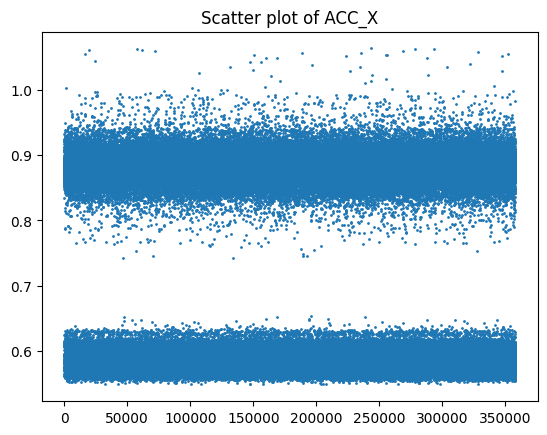

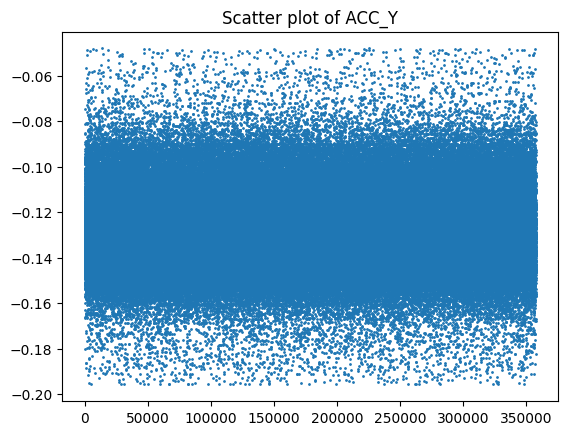

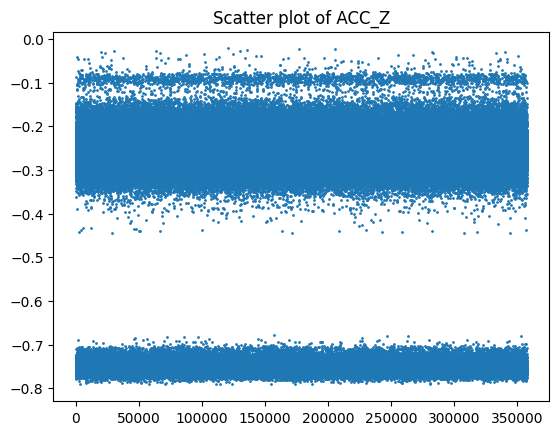

In [34]:
scatter_plot(df=df, columns='ACC_X')
scatter_plot(df=df, columns='ACC_Y')
scatter_plot(df=df, columns='ACC_Z')

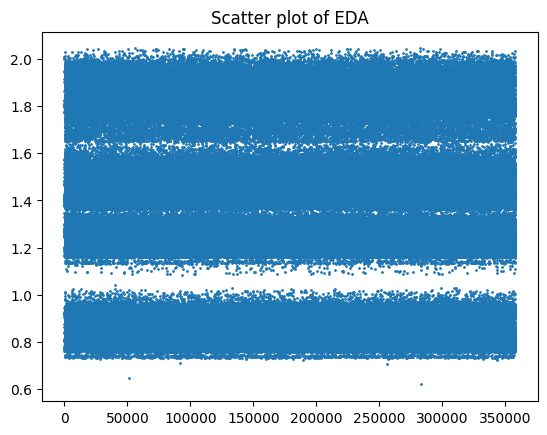

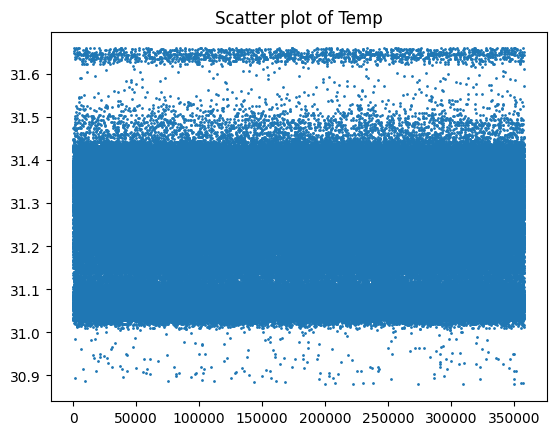

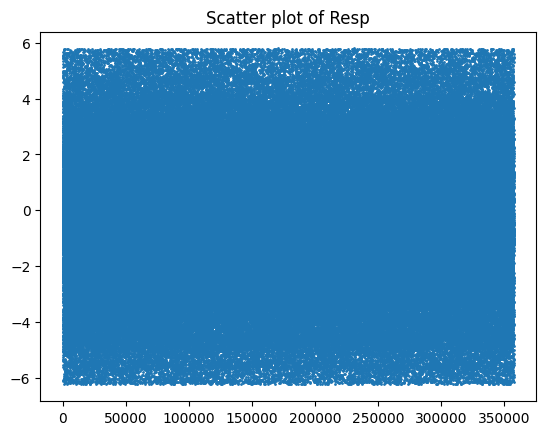

In [35]:
scatter_plot(df=df, columns='EDA')
scatter_plot(df=df, columns='Temp')
scatter_plot(df=df, columns='Resp')

### Handle outlier of EMG

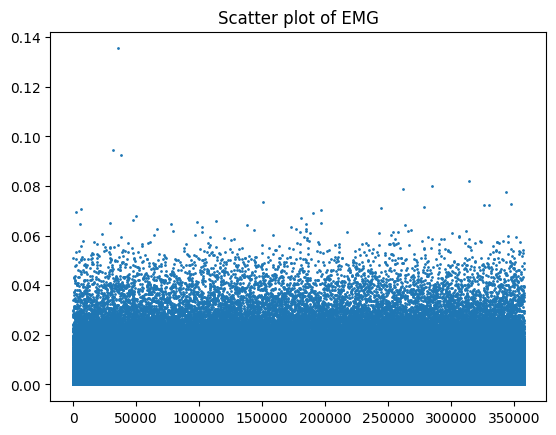

In [36]:
scatter_plot(df, "EMG")

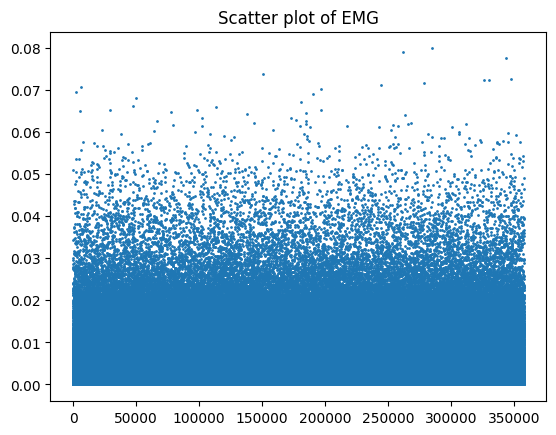

In [39]:
df = df[df["EMG"] < 0.08]
scatter_plot(df, "EMG")